In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer



from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df=pd.read_csv("email_spam.csv")
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [3]:
df.shape

(83448, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83448 entries, 0 to 83447
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   83448 non-null  int64 
 1   text    83448 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [5]:
df.describe()

,label
count,83448.000000
mean,0.526196
std,0.499316
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [6]:
df.columns

Index(['label', 'text'], dtype='object')

In [7]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [8]:
print(f"No of duplicated rows: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(df.shape)

No of duplicated rows: 0
(83448, 2)


In [9]:
df['label'].value_counts()

label
1    43910
0    39538
Name: count, dtype: int64

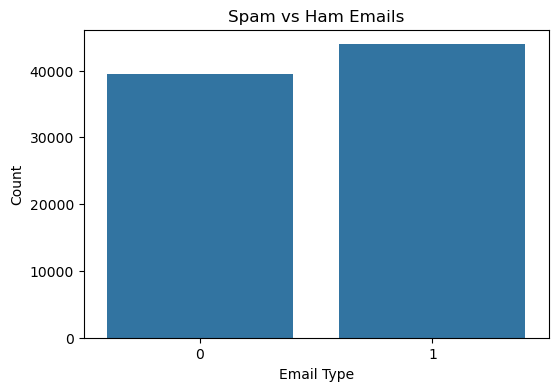

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='label',data=df)
plt.title("Spam vs Ham Emails")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

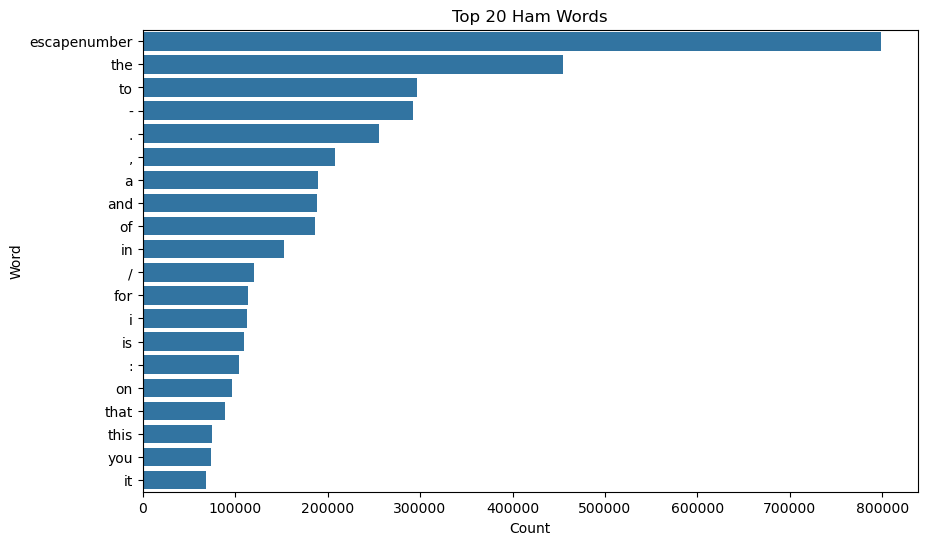

In [11]:
ham_words=' '.join(df[df['label']==0]['text']).split()

ham_common=Counter(ham_words).most_common(20)

ham_df=pd.DataFrame(ham_common,columns=['Word','Count'])

plt.figure(figsize=(10,6))

sns.barplot(x='Count',y='Word',data=ham_df)

plt.title("Top 20 Ham Words")

plt.show()

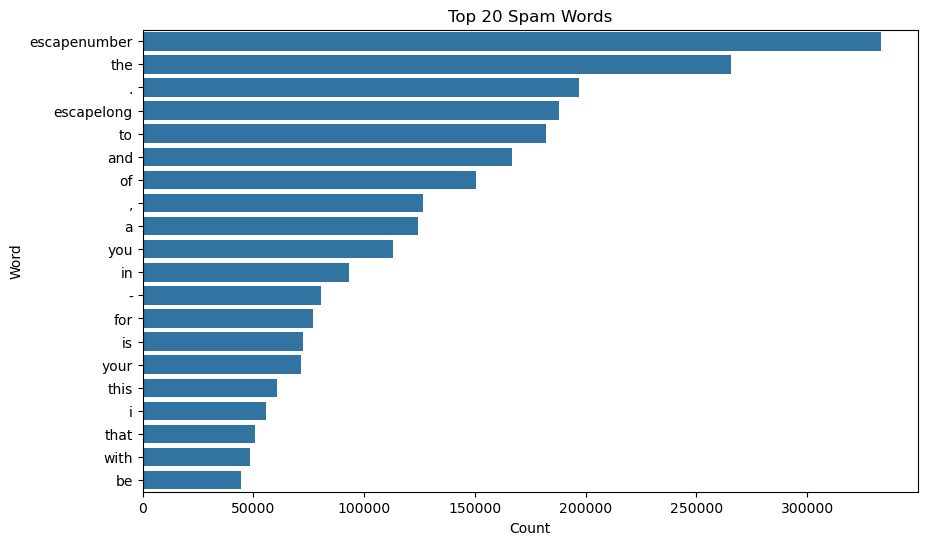

In [12]:
spam_words=' '.join(df[df['label']==1]['text']).split()

spam_common=Counter(spam_words).most_common(20)

spam_df=pd.DataFrame(spam_common,columns=['Word','Count'])

plt.figure(figsize=(10,6))

sns.barplot(x='Count',y='Word',data=spam_df)

plt.title("Top 20 Spam Words")

plt.show()

In [13]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    return text

df['text'] = df['text'].apply(clean_text)

In [14]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df['text'])

y = df['label']

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score
)

models = {

    'Multinomial Naive Bayes': MultinomialNB(),
    
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

     'SVM': LinearSVC(random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred) * 100

    f1 = f1_score(y_test, y_pred) * 100

    results.append([
        name,
        f"{accuracy:.2f}%",
        f"{f1:.2f}%"
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'F1 Score'
    ]
)

print("\nModel Comparison Results)\n")

print(results_df)


Model Comparison Results)

                     Model Accuracy F1 Score
0  Multinomial Naive Bayes   97.52%   97.60%
1      Logistic Regression   98.51%   98.59%
2                      SVM   99.05%   99.10%
3            Random Forest   83.27%   86.15%


In [17]:
svm=LinearSVC()

svm.fit(X_train,y_train)
svm_pred=svm.predict(X_test)
print("Accuracy:",accuracy_score(y_test,svm_pred)*100)

print("Precision:",precision_score(y_test,svm_pred)*100)

print("Recall:",recall_score(y_test,svm_pred)*100)

print("F1 Score:",f1_score(y_test,svm_pred)*100)


Accuracy: 99.0473337327741
Precision: 98.67452135493373
Recall: 99.5201096892139
F1 Score: 99.09551169008476


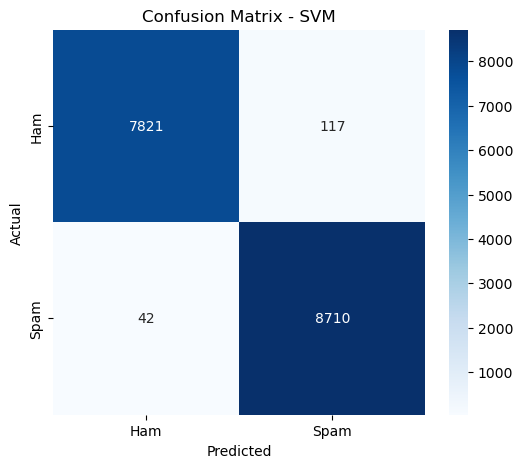

In [18]:
cm=confusion_matrix(y_test,svm_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues',
xticklabels=['Ham','Spam'],
yticklabels=['Ham','Spam'])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - SVM")

plt.show()

In [19]:
email = input("Enter an email message: ")

email_vector = tfidf.transform([email])

prediction = svm.predict(email_vector)

if prediction[0] == 1:
    print("\nThis is a Spam Email.")
else:
    print("\nThis is a Ham Email.")

Enter an email message:  Congratulations! You have won ₹50,000. Click the link below to claim your reward.



This is a Spam Email.
